In [1]:
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from IPython.display import display

In [4]:
# Load data from JSON file (array of objects)
with open('fetched_data_final_dedup_2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

# If your JSON is an array, not an object with "data" key:
df = pd.DataFrame(data)
# If label is boolean, you may want to convert it to int or str
df['label'] = df['label'].astype(int)  # Uncomment if needed

X = df['text']
y = df['label']

# show head
print(df.head())

                                                text  label
0                         mari riah ernia widyatmoko      0
1              taut hebat bonbon berani menang orang      1
2  wd keren mahaslot royal gan kasih juta hahaha ...      1
3                       jelek banget mantap mahaslot      1
4  wajah materialistis laku klaim freebet pepe kl...      1


In [6]:
# Stratified K-Fold Cross Validation
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []
cv_scores = []
fold_reports = []
fold = 0
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    accu = accuracy_score(y_test, y_pred)
    cv_scores.append(accu)
    print("Fold {}: {}".format(fold + 1, accu))
    # Collect metrics for this fold
    report = classification_report(y_test, y_pred, digits=4, output_dict=True, zero_division=0)
    fold_reports.append(report)
    display(pd.DataFrame(report).transpose())
    # fold += 1


# Calculate mean metrics
def mean_metric(metric):
    return np.mean([fold[metric]['f1-score'] for fold in fold_reports])

labels = sorted(list(set(y)))
metrics = ['precision', 'recall', 'f1-score']
mean_results = {}

# Per-class averages
for label in labels:
    mean_results[f"class {label}"] = {
        m: np.mean([fold[str(label)][m] for fold in fold_reports]) for m in metrics
    }

# Global averages
mean_results['accuracy'] = {"score": np.mean([fold['accuracy'] for fold in fold_reports])}
mean_results['macro avg'] = {
    m: np.mean([fold['macro avg'][m] for fold in fold_reports]) for m in metrics
}
mean_results['weighted avg'] = {
    m: np.mean([fold['weighted avg'][m] for fold in fold_reports]) for m in metrics
}

# Convert to DataFrame
results_df = pd.DataFrame(mean_results).T

print("Final averaged metrics across folds:")
display(results_df)

# Show per-fold accuracies as well
fold_acc_df = pd.DataFrame({
    "Fold": range(1, n_splits + 1),
    "Accuracy": cv_scores
})
print("Per-fold accuracy:")
display(fold_acc_df)

# Show overall confusion matrix
print("Confusion Matrix across all folds:")
display(pd.DataFrame(confusion_matrix(all_y_true, all_y_pred)))



Fold 1: 0.9009090909090909


,precision,recall,f1-score,support
0,0.904959,0.874251,0.889340,501.000000
1,0.897727,0.923205,0.910288,599.000000
accuracy,0.900909,0.900909,0.900909,0.900909
macro avg,0.901343,0.898728,0.899814,1100.000000
weighted avg,0.901021,0.900909,0.900747,1100.000000


Fold 2: 0.899090909090909


,precision,recall,f1-score,support
0,0.882353,0.898204,0.890208,501.000000
1,0.913559,0.899833,0.906644,599.000000
accuracy,0.899091,0.899091,0.899091,0.899091
macro avg,0.897956,0.899018,0.898426,1100.000000
weighted avg,0.899346,0.899091,0.899158,1100.000000


Fold 3: 0.9118181818181819


...

,precision,recall,f1-score,score
class 0,0.902644,0.897319,0.899858,NaN
class 1,0.914648,0.918825,0.916654,NaN
accuracy,NaN,NaN,NaN,0.909034
macro avg,0.908646,0.908072,0.908256,NaN
weighted avg,0.909180,0.909034,0.909006,NaN


Per-fold accuracy:


,Fold,Accuracy
0,1,0.900909
1,2,0.899091
2,3,0.911818
3,4,0.912648
4,5,0.917197
5,6,0.913558
6,7,0.921747
7,8,0.887170
8,9,0.907188
9,10,0.919017


Confusion Matrix across all folds:


,0,1
0,4492,514
1,486,5501


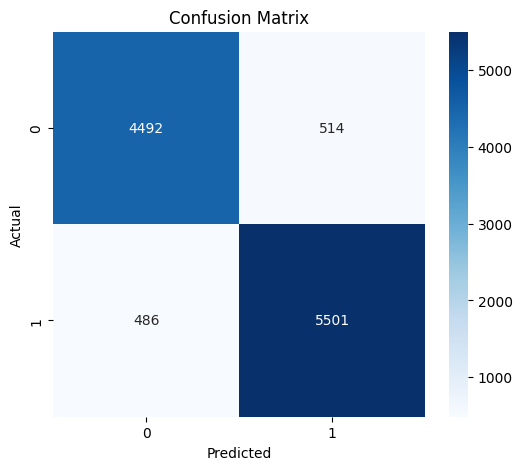

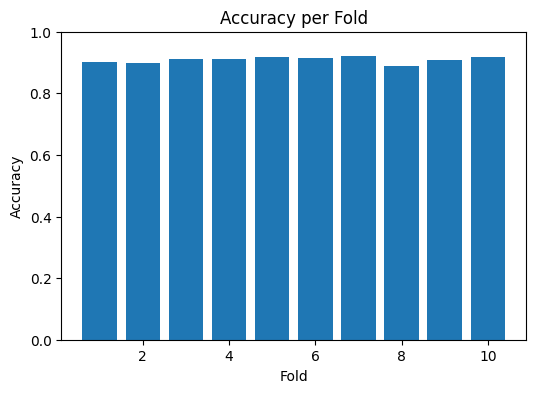

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# ...existing code...

# After printing the confusion matrix and classification report:
cm = confusion_matrix(all_y_true, all_y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Accuracy scores bar plot
plt.figure(figsize=(6, 4))
plt.bar(range(1, len(cv_scores) + 1), cv_scores)
plt.ylim(0, 1)
plt.xlabel('Fold')
plt.ylabel('Accuracy')
plt.title('Accuracy per Fold')
plt.show()

In [ ]:

# Optionally, train on all data for deployment
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model.fit(X_tfidf, y)

# Save the model and vectorizer for future use
joblib.dump(model, 'rf_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')

In [9]:
import pandas as pd
import numpy as np
import json
import joblib
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, make_scorer, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Load data from JSON file (array of objects)
with open('fetched_data_final_dedup_2.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

df = pd.DataFrame(data)
df['label'] = df['label'].astype(int)

X = df['text']
y = df['label']

# TF-IDF vectorization (fit on all data for search)
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(X)

# Choose number of splits (5 or 10)
n_splits = 10  # Change to 5 or 10 as needed
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Define parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

scoring = {
    'accuracy': make_scorer(accuracy_score),
    'f1': make_scorer(f1_score, average='weighted'),
    'precision': make_scorer(precision_score, average='weighted'),
    'recall': make_scorer(recall_score, average='weighted')
}

# Grid Search with StratifiedKFold
search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=skf,
    scoring=scoring,
    refit='f1',  # Optimize for weighted F1-score
    n_jobs=-1,
    verbose=2,
)

search.fit(X_tfidf, y)

print("Best parameters:", search.best_params_)
print("Best cross-validated score:", search.best_score_)

import pandas as pd

results = pd.DataFrame(search.cv_results_)
print(results[['param_n_estimators', 'mean_test_accuracy', 'mean_test_f1', 'mean_test_precision', 'mean_test_recall']])


# Save model and vectorizer for future use
joblib.dump(search.best_estimator_, 'result/rf_model_best.pkl')
joblib.dump(vectorizer, 'result/tfidf_vectorizer.pkl')

Fitting 10 folds for each of 72 candidates, totalling 720 fits
Best parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 300}
Best cross-validated score: 0.9126627470888662
    param_n_estimators  mean_test_accuracy  mean_test_f1  mean_test_precision  \
0                  100            0.910216      0.910199             0.910322   
1                  200            0.910762      0.910737             0.910845   
2                  300            0.910944      0.910926             0.911032   
3                  100            0.910399      0.910337             0.910415   
4                  200            0.911763      0.911696             0.911828   
..                 ...                 ...           ...                  ...   
67                 200            0.892568      0.892775             0.896281   
68                 300            0.893478      0.893683             0.896984   
69                 100            0.893023      0.8

['result/tfidf_vectorizer.pkl']

In [4]:
from sklearn.svm import SVC

# Stratified K-Fold Cross Validation
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []
cv_scores = []
fold_reports = []
fold = 0
for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    vectorizer = TfidfVectorizer(max_features=5000)
    X_train_tfidf = vectorizer.fit_transform(X_train)
    X_test_tfidf = vectorizer.transform(X_test)

    model = SVC(kernel='rbf', C=1.0, class_weight='balanced', random_state=42)
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    accu = accuracy_score(y_test, y_pred)
    cv_scores.append(accu)
    print("Fold {}: {}".format(fold + 1, accu))
    # Collect metrics for this fold
    report = classification_report(y_test, y_pred, digits=4, output_dict=True, zero_division=0)
    fold_reports.append(report)
    display(pd.DataFrame(report).transpose())
    # fold += 1


# Calculate mean metrics
def mean_metric(metric):
    return np.mean([fold[metric]['f1-score'] for fold in fold_reports])

labels = sorted(list(set(y)))
metrics = ['precision', 'recall', 'f1-score']
mean_results = {}

# Per-class averages
for label in labels:
    mean_results[f"class {label}"] = {
        m: np.mean([fold[str(label)][m] for fold in fold_reports]) for m in metrics
    }

# Global averages
mean_results['accuracy'] = {"score": np.mean([fold['accuracy'] for fold in fold_reports])}
mean_results['macro avg'] = {
    m: np.mean([fold['macro avg'][m] for fold in fold_reports]) for m in metrics
}
mean_results['weighted avg'] = {
    m: np.mean([fold['weighted avg'][m] for fold in fold_reports]) for m in metrics
}

# Convert to DataFrame
results_df = pd.DataFrame(mean_results).T

print("Final averaged metrics across folds:")
display(results_df)

# Show per-fold accuracies as well
fold_acc_df = pd.DataFrame({
    "Fold": range(1, n_splits + 1),
    "Accuracy": cv_scores
})
print("Per-fold accuracy:")
display(fold_acc_df)

# Show overall confusion matrix
print("Confusion Matrix across all folds:")
display(pd.DataFrame(confusion_matrix(all_y_true, all_y_pred)))


Fold 1: 0.9468556244464128


,precision,recall,f1-score,support
0,0.933573,0.957643,0.945455,543.000000
1,0.959790,0.936860,0.948187,586.000000
accuracy,0.946856,0.946856,0.946856,0.946856
macro avg,0.946681,0.947251,0.946821,1129.000000
weighted avg,0.947181,0.946856,0.946873,1129.000000


Fold 2: 0.9486271036315324


,precision,recall,f1-score,support
0,0.926186,0.970534,0.947842,543.000000
1,0.971429,0.928328,0.949389,586.000000
accuracy,0.948627,0.948627,0.948627,0.948627
macro avg,0.948807,0.949431,0.948615,1129.000000
weighted avg,0.949669,0.948627,0.948645,1129.000000


Fold 3: 0.9512843224092117


...

,precision,recall,f1-score,score
class 0,0.923492,0.960773,0.941709,NaN
class 1,0.962309,0.926109,0.943808,NaN
accuracy,NaN,NaN,NaN,0.942781
macro avg,0.942901,0.943441,0.942759,NaN
weighted avg,0.943640,0.942781,0.942799,NaN


Per-fold accuracy:


,Fold,Accuracy
0,1,0.946856
1,2,0.948627
2,3,0.951284
3,4,0.944198
4,5,0.936227
5,6,0.946856
6,7,0.940655
7,8,0.944198
8,9,0.929141
9,10,0.939770


Confusion Matrix across all folds:


,0,1
0,5217,213
1,433,5427
